<a href="https://colab.research.google.com/github/teevvr7/Football_penalty/blob/main/DeeplearningTEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install dependencies
!pip install ultralytics opencv-python mediapipe

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [1]:


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check your Drive structure
print("Checking your Drive folder structure:")
!ls -la "/content/drive/MyDrive/"

# Copy from Drive to Colab for faster training (RECOMMENDED)
import shutil
import os

# Copy entire project to Colab
source_path = "/content/drive/MyDrive/penalty_project"
dest_path = "/content/penalty_project"

if os.path.exists(source_path):
    if os.path.exists(dest_path):
        shutil.rmtree(dest_path)  # Remove existing
    shutil.copytree(source_path, dest_path)
    print("✓ Copied files from Drive to Colab")
else:
    print("⚠ penalty_project folder not found in Drive")
    print("Please make sure your files are in: /content/drive/MyDrive/penalty_project/")

# Create dataset.yaml in Colab
#yaml_content = """path: /content/penalty_project/datasets
#train: images/train
#val: images/val

#nc: 4
#names: ['kicker', 'goalkeeper', 'ball', 'goalpost']
#"""

#with open('/content/penalty_project/dataset.yaml', 'w') as f:
   # f.write(yaml_content)

#print("✓ dataset.yaml created")
#print("✓ Setup complete!")

Mounted at /content/drive
Checking your Drive folder structure:
total 33224
-rw------- 1 root root  141712 Jun  6  2024  2e90d0c1-e67c-4512-9b38-80a7e931e4f2.jpeg
-rw------- 1 root root  114244 Apr 15 09:16 '5.Individual SCL1 -video In the Shoes of the Entrepreneur(217093).pdf'
-rw------- 1 root root  166691 May 27  2024  ae58282b-0a94-4b59-880d-4eb52ec85e5d.jpeg
-rw------- 1 root root     180 Jan  9  2025 'CEL GROUP 4-discussion plan.gdoc'
drwx------ 2 root root    4096 Jun 12  2024 'Colab Notebooks'
-rw------- 1 root root     180 Jan  9  2024 'Copy of ASURAN CHAMPIONSHIP 2.0 CREW RECRUITMENT (Responses).gsheet'
-rw------- 1 root root 2955861 Apr  3  2024  DC00949F-E821-4A66-95EE-A6B6B084E4BF.jpeg
-rw------- 1 root root  745924 Nov 24  2024  donut.blend
-rw------- 1 root root     180 Jul  6 10:53 'Draft of FYP teev(217093).gdoc'
-rw------- 1 root root  126129 May 16 12:01  fbf6f6c1-d3c0-4658-ba56-e144120f454f.jpeg
-rw------- 1 root root  154157 Nov 15  2024  food_consumption.csv
-rw--

In [2]:
!cp -r "/content/drive/MyDrive/yolov8n.pt" "/content/"

In [3]:
!cp -r "/content/drive/MyDrive/runs" "/content/"

In [4]:
!cp -r "/content/drive/MyDrive/yolo11n.pt" "/content/"

##checking the paths

In [ ]:
# Check if video files match annotation names
import os

videos_path = "/content/penalty_project/videos"
labels_path = "/content/penalty_project/datasets/labels/train"

# Get video names from annotations
annotation_files = os.listdir(labels_path)
video_names_from_annotations = set([f.split('_')[0] for f in annotation_files if f.endswith('.txt')])

# Get actual video files
video_files = [f.replace('.mp4', '') for f in os.listdir(videos_path) if f.endswith('.mp4')]

print("Video names from annotations:", sorted(video_names_from_annotations))
print("Actual video files:", sorted(video_files))
print("Match:", video_names_from_annotations == set(video_files))

if video_names_from_annotations.issubset(set(video_files)):
    print("✅ All annotation videos found!")
else:
    missing = video_names_from_annotations - set(video_files)
    print(f"❌ Missing videos: {missing}")

Video names from annotations: ['036right', '038left', '043outside', '067center', '108outside', '109center']
Actual video files: ['036right', '038left', '040right', '042left', '043outside', '067center', '108outside', '109center']
Match: False
✅ All annotation videos found!


#frame extraction (train only checking for it's existense first)

In [ ]:
import cv2
import os
from tqdm import tqdm

def extract_frames_with_annotations():
    """Extract frames that match your existing annotation files"""

    videos_path = "/content/penalty_project/videos"
    images_train_path = "/content/penalty_project/datasets/images/train"
    labels_train_path = "/content/penalty_project/datasets/labels/train"

    # Create images directory if not exists
    os.makedirs(images_train_path, exist_ok=True)

    # Get all annotation files
    annotation_files = [f for f in os.listdir(labels_train_path) if f.endswith('.txt')]

    print(f"Found {len(annotation_files)} annotation files")

    # Group annotations by video
    video_annotations = {}
    for ann_file in annotation_files:
        # Extract video name: "109center_000001.txt" -> "109center"
        video_name = ann_file.split('_')[0]
        if video_name not in video_annotations:
            video_annotations[video_name] = []
        video_annotations[video_name].append(ann_file)

    # Process each video
    for video_name, ann_files in video_annotations.items():
        video_path = os.path.join(videos_path, f"{video_name}.mp4")

        if not os.path.exists(video_path):
            print(f"⚠ Video not found: {video_path}")
            continue

        print(f"Processing {video_name}...")

        cap = cv2.VideoCapture(video_path)
        frame_count = 0

        # Extract frames that have annotations
        for ann_file in tqdm(ann_files):
            # Extract frame number: "109center_000123.txt" -> 123
            frame_num = int(ann_file.split('_')[-1].split('.')[0])

            # Seek to the specific frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ret, frame = cap.read()

            if ret:
                # Save image with same name as annotation
                image_filename = ann_file.replace('.txt', '.jpg')
                image_path = os.path.join(images_train_path, image_filename)
                cv2.imwrite(image_path, frame)
                frame_count += 1
            else:
                print(f"⚠ Could not read frame {frame_num} from {video_name}")

        cap.release()
        print(f"✓ Extracted {frame_count} frames from {video_name}")

# Run the extraction
extract_frames_with_annotations()

Found 493 annotation files
Processing 109center...


100%|██████████| 98/98 [00:23<00:00,  4.12it/s]


✓ Extracted 98 frames from 109center
Processing 043outside...


100%|██████████| 77/77 [00:17<00:00,  4.31it/s]


✓ Extracted 77 frames from 043outside
Processing 108outside...


...

✓ Extracted 64 frames from 067center
Processing 038left...


100%|██████████| 61/61 [00:11<00:00,  5.32it/s]


✓ Extracted 61 frames from 038left
Processing 036right...


100%|██████████| 99/99 [00:25<00:00,  3.84it/s]

✓ Extracted 99 frames from 036right


## both train and validation extraction (skips the existing files)

In [ ]:
import cv2
import os
from tqdm import tqdm

def extract_all_frames_with_annotations():
    """Extract frames for both train and validation sets"""

    videos_path = "/content/penalty_project/videos"

    # Process both train and validation sets
    for dataset_type in ['train', 'val']:
        images_path = f"/content/penalty_project/datasets/images/{dataset_type}"
        labels_path = f"/content/penalty_project/datasets/labels/{dataset_type}"

        # Create images directory if not exists
        os.makedirs(images_path, exist_ok=True)

        # Check if labels folder exists
        if not os.path.exists(labels_path):
            print(f"⚠ No {dataset_type} labels folder found, skipping...")
            continue

        # Get all annotation files
        annotation_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]

        if not annotation_files:
            print(f"⚠ No annotation files found in {dataset_type}, skipping...")
            continue

        print(f"\n📁 Processing {dataset_type.upper()} set:")
        print(f"Found {len(annotation_files)} annotation files")

        # Group annotations by video
        video_annotations = {}
        for ann_file in annotation_files:
            video_name = ann_file.split('_')[0]
            if video_name not in video_annotations:
                video_annotations[video_name] = []
            video_annotations[video_name].append(ann_file)

        # Process each video
        for video_name, ann_files in video_annotations.items():
            video_path = os.path.join(videos_path, f"{video_name}.mp4")

            if not os.path.exists(video_path):
                print(f"⚠ Video not found: {video_path}")
                continue

            print(f"Processing {video_name}...")

            cap = cv2.VideoCapture(video_path)
            frame_count = 0

            # Extract frames that have annotations
            for ann_file in tqdm(ann_files):
                frame_num = int(ann_file.split('_')[-1].split('.')[0])

                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
                ret, frame = cap.read()

                if ret:
                    image_filename = ann_file.replace('.txt', '.jpg')
                    image_path = os.path.join(images_path, image_filename)
                    cv2.imwrite(image_path, frame)
                    frame_count += 1
                else:
                    print(f"⚠ Could not read frame {frame_num} from {video_name}")

            cap.release()
            print(f"✓ Extracted {frame_count} frames from {video_name}")

# Run extraction for both train and val
extract_all_frames_with_annotations()


📁 Processing TRAIN set:
Found 493 annotation files
Processing 109center...


100%|██████████| 98/98 [00:22<00:00,  4.44it/s]


✓ Extracted 98 frames from 109center
Processing 043outside...


100%|██████████| 77/77 [00:20<00:00,  3.76it/s]


✓ Extracted 77 frames from 043outside
Processing 108outside...


...

✓ Extracted 99 frames from 036right

📁 Processing VAL set:
Found 137 annotation files
Processing 042left...


100%|██████████| 67/67 [00:13<00:00,  5.12it/s]


✓ Extracted 67 frames from 042left
Processing 040right...


100%|██████████| 70/70 [00:14<00:00,  4.88it/s]

✓ Extracted 70 frames from 040right


extraction settled

## YOLO MODEL TRAINING

VERIFICATION OF DATASET

In [ ]:
# Final verification before training
import os

def verify_dataset():
    train_images = set([f.replace('.jpg', '') for f in os.listdir('/content/penalty_project/datasets/images/train') if f.endswith('.jpg')])
    train_labels = set([f.replace('.txt', '') for f in os.listdir('/content/penalty_project/datasets/labels/train') if f.endswith('.txt')])

    val_images = set([f.replace('.jpg', '') for f in os.listdir('/content/penalty_project/datasets/images/val') if f.endswith('.jpg')])
    val_labels = set([f.replace('.txt', '') for f in os.listdir('/content/penalty_project/datasets/labels/val') if f.endswith('.txt')])

    print("📊 DATASET SUMMARY:")
    print(f"Train images: {len(train_images)}")
    print(f"Train labels: {len(train_labels)}")
    print(f"Val images: {len(val_images)}")
    print(f"Val labels: {len(val_labels)}")

    # Check matches
    train_match = train_images == train_labels
    val_match = val_images == val_labels

    print(f"✅ Train set match: {train_match}")
    print(f"✅ Validation set match: {val_match}")

    return train_match and val_match

if verify_dataset():
    print("🎉 Dataset is ready for training!")
else:
    print("❌ Dataset has issues, please check file matching")

📊 DATASET SUMMARY:
Train images: 493
Train labels: 493
Val images: 137
Val labels: 137
✅ Train set match: True
✅ Validation set match: True
🎉 Dataset is ready for training!


YOLO training !!!

In [ ]:
from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:


# Check if GPU is available
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load a pretrained model (start with small model for quick testing)
model = YOLO('yolov8n.pt')  # 'n' = nano (fastest), 's' = small (better accuracy)

# Train the model
results = model.train(
    data='/content/penalty_project/dataset.yaml',
    epochs=100,           # Start with 100 epochs
    imgsz=640,           # Image size
    batch=4,            # Batch size (adjust based on GPU memory)
    device=0,            # Use GPU
    save=True,           # Save results
    exist_ok=True,       # Overwrite existing
    patience=10,         # Stop if no improvement for 10 epochs
    pretrained=True      # Use pretrained weights
)

print("✅ Training completed!")

GPU available: True
GPU: Tesla T4
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/penalty_project/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

##testing with validation dataset

In [ ]:
from ultralytics import YOLO
import cv2

In [ ]:


# Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Test on a validation video
results = model.predict(
    source='/content/penalty_project/videos/042left.mp4',  # Use your val video
    save=True,
    conf=0.5,  # Confidence threshold
    show=True
)

print("✅ Prediction completed!")


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/67) /content/penalty_project/videos/042left.mp4: 384x640 1 kicker, 1 goalkeeper, 1 ball, 1 goalpost, 44.0ms
video 1/1 (frame 2/67) /content/penalty_project/videos/042left.mp4: 384x640 1 kicker, 1 goalkeeper, 1 ball, 1 goalpost, 8.9ms
video 1/1 (frame 3/67) /content/penalty_project/videos/042left.mp4: 384x640 1 kicker, 1 goalkeeper, 1 ball, 1 goalpost, 7.6ms
video 1/1 (frame 4/67) /content/penalty_project/videos/042left.mp4: 384x640 1

In [ ]:
# Display sample detection results
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Visualize Detections

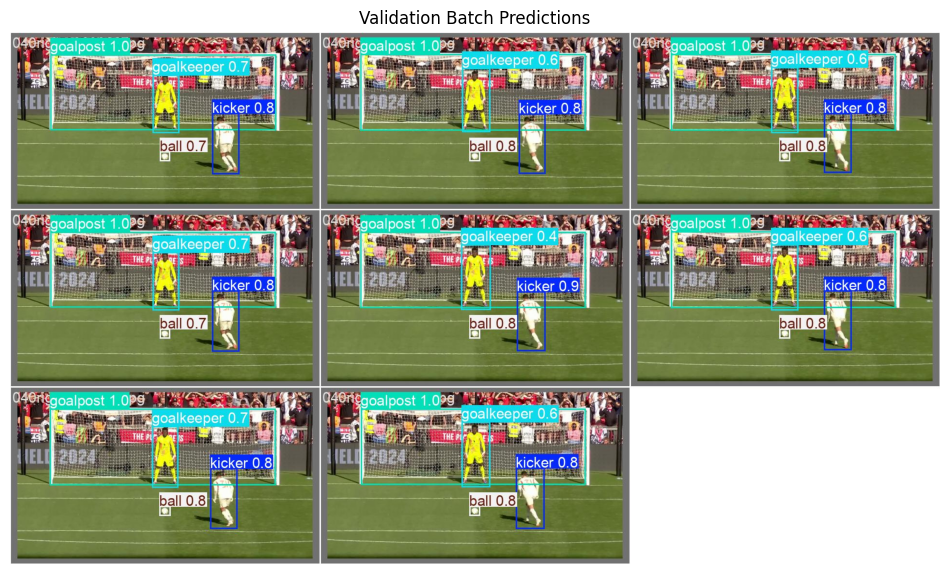

In [ ]:


# Show a result image
result_image_path = '/content/runs/detect/train/val_batch0_pred.jpg'
if os.path.exists(result_image_path):
    img = mpimg.imread(result_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Validation Batch Predictions')
    plt.show()

Check Training Plots

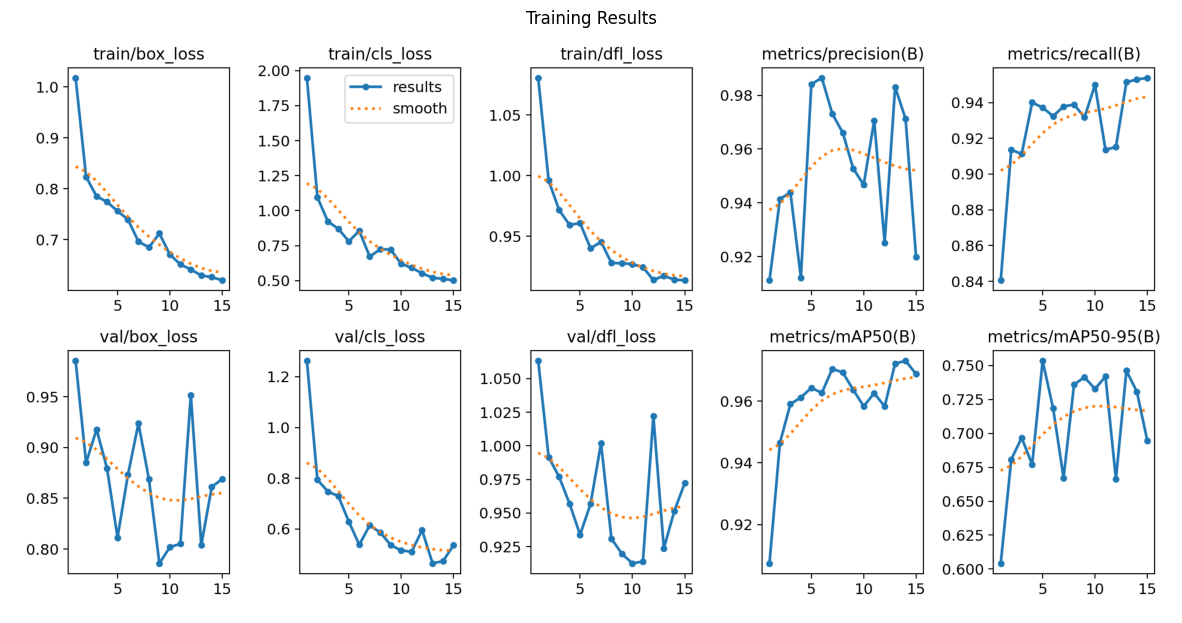

In [ ]:
# Show training results
results_image = '/content/runs/detect/train/results.png'
if os.path.exists(results_image):
    img = mpimg.imread(results_image)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Results')
    plt.show()

##saving in drive first

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/penalty_project /content/drive/MyDrive/

In [ ]:
!cp -r /content/runs /content/drive/MyDrive/

In [ ]:
!cp /content/yolo11n.pt /content/drive/MyDrive/

In [ ]:
!cp /content/yolov8n.pt /content/drive/MyDrive/

##Pose Estimation & LSTM

Extract Kicker Poses Using YOLO + MediaPipe

In [5]:
import cv2
import mediapipe as mp
from ultralytics import YOLO
import numpy as np

# Load your trained YOLO model
yolo_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, model_complexity=1)

def extract_pose_sequence(video_path, sequence_length=30):
    """
    Extract pose sequences from video for LSTM training
    """
    cap = cv2.VideoCapture(video_path)
    pose_sequences = []

    frames_processed = 0
    while frames_processed < sequence_length:
        ret, frame = cap.read()
        if not ret:
            break

        # Detect kicker using YOLO
        results = yolo_model(frame)

        # Find kicker bounding box (class 0)
        kicker_boxes = []
        for result in results:
            boxes = result.boxes
            for box in boxes:
                if int(box.cls) == 0:  # kicker class
                    kicker_boxes.append(box.xyxy[0].cpu().numpy())

        if kicker_boxes:
            # Use the first kicker detected
            x1, y1, x2, y2 = map(int, kicker_boxes[0])
            kicker_crop = frame[y1:y2, x1:x2]

            # Extract pose landmarks
            rgb_frame = cv2.cvtColor(kicker_crop, cv2.COLOR_BGR2RGB)
            pose_results = pose.process(rgb_frame)

            if pose_results.pose_landmarks:
                landmarks = []
                for landmark in pose_results.pose_landmarks.landmark:
                    landmarks.extend([landmark.x, landmark.y, landmark.z, landmark.visibility])
                pose_sequences.append(landmarks)
                frames_processed += 1

    cap.release()
    return np.array(pose_sequences)

# Test on one video
video_path = "/content/penalty_project/videos/109center.mp4"
pose_sequence = extract_pose_sequence(video_path)
print(f"Extracted pose sequence shape: {pose_sequence.shape}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 (no detections), 69.1ms
Speed: 17.7ms preprocess, 69.1ms inference, 90.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.3ms
Speed: 4.2ms preprocess, 7.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.6ms
Speed: 4.7ms preprocess, 6.6ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.8ms
Speed: 3.4ms preprocess, 6.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.8ms
Speed: 3.2ms preprocess, 5.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


0: 384x640 (no detections), 8.1ms
Speed: 3.0ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.1ms
Speed: 3.3ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.0ms
Speed: 3.4ms preprocess, 7.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.0ms
Speed: 3.3ms preprocess, 8.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.1ms
Speed: 3.1ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.4ms
Speed: 4.3ms preprocess, 11.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 13.8ms
Speed: 5.2ms preprocess, 13.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.6ms
Speed: 3.0ms preprocess, 9.6ms inference, 0.6

Prepare LSTM Dataset

In [6]:
def create_lstm_dataset(videos_folder, labels_folder):
    """
    Create LSTM dataset from all videos
    """
    X_sequences = []  # Pose sequences
    y_labels = []     # Shot regions (0,1,2,3)

    # Process each video
    for video_file in os.listdir(videos_folder):
        if video_file.endswith('.mp4'):
            video_path = os.path.join(videos_folder, video_file)
            video_name = video_file.replace('.mp4', '')

            # Extract pose sequence
            pose_seq = extract_pose_sequence(video_path)

            if len(pose_seq) == 30:  # Only use complete sequences
                X_sequences.append(pose_seq)

                # Determine label from video name
                if 'center' in video_name:
                    y_labels.append(2)  # Center region
                elif 'left' in video_name:
                    y_labels.append(1)  # Left region
                elif 'right' in video_name:
                    y_labels.append(3)  # Right region
                else:
                    y_labels.append(0)  # Outside

    return np.array(X_sequences), np.array(y_labels)

# Create dataset
X, y = create_lstm_dataset("/content/penalty_project/videos",
                          "/content/penalty_project/datasets/labels/train")
print(f"LSTM Dataset: {X.shape} sequences, {y.shape} labels")


0: 384x640 (no detections), 9.0ms
Speed: 3.5ms preprocess, 9.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.3ms
Speed: 3.5ms preprocess, 7.3ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.2ms
Speed: 2.7ms preprocess, 8.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.9ms
Speed: 3.1ms preprocess, 6.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.7ms
Speed: 3.2ms preprocess, 6.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.7ms
Speed: 2.9ms preprocess, 7.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 5.9ms
Speed: 3.8ms preprocess, 5.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.9ms
Speed: 3.1ms preprocess, 6.9ms inference, 0.5ms 